# 📝 EDA — Text Data: Stanford Question Answering Dataset (SQuAD 1.1)
**Course:** P4AI-DS (CO3135) — HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [SQuAD 1.1](https://huggingface.co/datasets/rajpurkar/squad)

**Description:** 98,169 question-answer pairs derived from 442 Wikipedia articles. Each sample contains a context paragraph, a question, and an extractive answer span.

## 0. Setup & Imports

In [ ]:
# Enhanced duplicate detection metrics for JSON export
if 'json_data' in dir() or 'eda_data' in dir():
    data_dict = json_data if 'json_data' in dir() else eda_data
    
    # Update with comprehensive duplicate metrics
    data_dict['duplicate_analysis'] = {
        'questions': {
            'total_duplicates': int(df['question'].duplicated().sum()),
            'unique_count': int(df['question'].nunique()),
            'duplicate_percentage': float((df['question'].duplicated().sum() / len(df)) * 100)
        }
    }
    
    # Contexts
    if 'context' in df.columns:
        data_dict['duplicate_analysis']['contexts'] = {
            'total_duplicates': int(df['context'].duplicated().sum()),
            'unique_count': int(df['context'].nunique()),
            'duplicate_percentage': float((df['context'].duplicated().sum() / len(df)) * 100)
        }
    
    # Answers
    answer_col = None
    for col in ['answer', 'answer_text', 'answers']:
        if col in df.columns:
            answer_col = col
            break
    
    if answer_col:
        data_dict['duplicate_analysis']['answers'] = {
            'total_duplicates': int(df[answer_col].duplicated().sum()),
            'unique_count': int(df[answer_col].nunique()),
            'duplicate_percentage': float((df[answer_col].duplicated().sum() / len(df)) * 100)
        }
    
    # Complete rows
    data_dict['duplicate_analysis']['complete_rows'] = {
        'total_duplicates': int(df.duplicated().sum()),
        'unique_rows': int(len(df) - df.duplicated().sum()),
        'duplicate_percentage': float((df.duplicated().sum() / len(df)) * 100)
    }
    
    print("✓ Enhanced duplicate metrics added to JSON export")


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json as json_lib
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from datasets import load_dataset
from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk import ngrams as nltk_ngrams

# === LOG SETUP ===
LOG_FILE = 'eda_text_stats.txt'
JSON_FILE = 'eda_text_data.json'
json_data = {}

def log(text, also_print=True):
    with open(LOG_FILE, 'a') as f:
        f.write(text + '\n')
    if also_print:
        print(text)

def save_json():
    with open(JSON_FILE, 'w') as f:
        json_lib.dump(json_data, f, indent=2, default=str)

with open(LOG_FILE, 'w') as f:
    f.write('=' * 70 + '\n')
    f.write('EDA TEXT STATS — SQuAD 1.1\n')
    f.write('=' * 70 + '\n\n')

STOP_WORDS = set(stopwords.words('english'))

print('✅ Setup complete!')

✅ Setup complete!


In [2]:
print('📥 Downloading SQuAD 1.1 from HuggingFace...')
dataset = load_dataset('rajpurkar/squad')

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
df = pd.concat([train_df, val_df], ignore_index=True)

# Extract answer text and compute helper columns
df['answer_text'] = df['answers'].apply(lambda x: x['text'][0] if len(x['text']) > 0 else '')
df['answer_start'] = df['answers'].apply(lambda x: x['answer_start'][0] if len(x['answer_start']) > 0 else 0)
df['num_answers'] = df['answers'].apply(lambda x: len(x['text']))

# Word/char counts
df['context_word_count'] = df['context'].apply(lambda x: len(x.split()))
df['context_char_count'] = df['context'].apply(len)
df['question_word_count'] = df['question'].apply(lambda x: len(x.split()))
df['question_char_count'] = df['question'].apply(len)
df['answer_word_count'] = df['answer_text'].apply(lambda x: len(x.split()))
df['answer_char_count'] = df['answer_text'].apply(len)

# Question type
df['question_type'] = df['question'].apply(lambda x: x.split()[0].lower() if len(x.split()) > 0 else '')
main_types = {'what': 'What', 'who': 'Who', 'when': 'When', 'where': 'Where',
              'how': 'How', 'which': 'Which', 'why': 'Why', 'in': 'In'}
df['question_category'] = df['question_type'].map(main_types).fillna('Other')

print(f'✅ Loaded {len(df)} QA pairs')

📥 Downloading SQuAD 1.1 from HuggingFace...
✅ Loaded 98169 QA pairs


## 1. 📚 Analysis Methodology

| Analysis Type | Purpose | Key Metrics |
|---|---|---|
| **Text Length** | Assess document length distributions | Word count, Char count, Min/Max/Mean |
| **Word Frequency** | Identify dominant vocabulary | Top unigrams, Stop word ratio |
| **N-gram Analysis** | Discover common phrases | Top bigrams, Top trigrams |
| **Category Distribution** | Evaluate label balance | Category counts, Imbalance ratio |
| **Category-Specific** | Compare topics | Top words per category, Length by category |

**💡 Key Principle:** Text EDA reveals vocabulary patterns, topic structure, and preprocessing needs before NLP modeling.

## 2. 📊 Dataset Overview

In [3]:
log('=== SECTION 2: DATASET OVERVIEW ===')

n_total = len(df)
n_train = len(train_df)
n_val = len(val_df)
n_unique_titles = df['title'].nunique()
n_unique_contexts = df['context'].nunique()
n_question_types = df['question_category'].nunique()

log(f'Total QA pairs: {n_total}')
log(f'Training set: {n_train}')
log(f'Validation set: {n_val}')
log(f'Unique articles (titles): {n_unique_titles}')
log(f'Unique context paragraphs: {n_unique_contexts}')
log(f'Avg questions per article: {n_total/n_unique_titles:.1f}')
log(f'Avg questions per context: {n_total/n_unique_contexts:.1f}')
log(f'Question type categories: {n_question_types}')

# Missing values
missing = df[['id', 'title', 'context', 'question', 'answer_text']].isnull().sum()
log(f'\nMissing values: {missing.sum()} total')
log(f'Duplicate questions: {df["question"].duplicated().sum()}')

# Feature descriptions
feature_desc = [
    {'name': 'id', 'type': 'Identifier', 'description': 'Unique ID for each QA pair'},
    {'name': 'title', 'type': 'Categorical', 'description': 'Wikipedia article title (topic)'},
    {'name': 'context', 'type': 'Text', 'description': 'Wikipedia paragraph containing the answer'},
    {'name': 'question', 'type': 'Text', 'description': 'Question posed about the context'},
    {'name': 'answers', 'type': 'Text + Position', 'description': 'Answer text and its start position in context'}
]

json_data['dataset_overview'] = {
    'n_total': n_total, 'n_train': n_train, 'n_val': n_val,
    'n_unique_titles': n_unique_titles, 'n_unique_contexts': n_unique_contexts,
    'avg_questions_per_article': round(n_total/n_unique_titles, 1),
    'avg_questions_per_context': round(n_total/n_unique_contexts, 1),
    'missing_values': {str(k): int(v) for k, v in missing.items()},
    'duplicate_questions': int(df['question'].duplicated().sum()),
    'feature_descriptions': feature_desc
}
save_json()

print('\n📋 Sample data:')
df[['title', 'context', 'question', 'answer_text']].head(3)

=== SECTION 2: DATASET OVERVIEW ===
Total QA pairs: 98169
Training set: 87599
Validation set: 10570
Unique articles (titles): 490
Unique context paragraphs: 20958
Avg questions per article: 200.3
Avg questions per context: 4.7
Question type categories: 9

Missing values: 0 total
Duplicate questions: 281

📋 Sample data:


,title,context,question,answer_text
0,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,Saint Bernadette Soubirous
1,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,a copper statue of Christ
2,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,the Main Building


## 🔍 Enhanced Duplicate Detection

Comprehensive duplicate analysis across questions, contexts, and answers.

In [ ]:
# Enhanced Duplicate Detection for Text Data
print(f"\n{'='*60}")
print("COMPREHENSIVE DUPLICATE DETECTION")
print(f"{'='*60}\n")

# 1. Duplicate Questions (already exists, but enhance)
dup_questions = df['question'].duplicated().sum()
dup_q_pct = (dup_questions / len(df)) * 100
print(f"1. DUPLICATE QUESTIONS:")
print(f"   Total: {dup_questions:,} ({dup_q_pct:.2f}%)")
print(f"   Unique questions: {df['question'].nunique():,}\n")

# 2. Duplicate Contexts
if 'context' in df.columns:
    dup_contexts = df['context'].duplicated().sum()
    dup_c_pct = (dup_contexts / len(df)) * 100
    print(f"2. DUPLICATE CONTEXTS:")
    print(f"   Total: {dup_contexts:,} ({dup_c_pct:.2f}%)")
    print(f"   Unique contexts: {df['context'].nunique():,}\n")

# 3. Duplicate Answers
answer_col = None
for col in ['answer', 'answer_text', 'answers']:
    if col in df.columns:
        answer_col = col
        break

if answer_col:
    dup_answers = df[answer_col].duplicated().sum()
    dup_a_pct = (dup_answers / len(df)) * 100
    print(f"3. DUPLICATE ANSWERS:")
    print(f"   Total: {dup_answers:,} ({dup_a_pct:.2f}%)")
    print(f"   Unique answers: {df[answer_col].nunique():,}\n")

# 4. Duplicate Titles (if exists)
if 'title' in df.columns:
    dup_titles = df['title'].duplicated().sum()
    dup_t_pct = (dup_titles / len(df)) * 100
    print(f"4. DUPLICATE TITLES:")
    print(f"   Total: {dup_titles:,} ({dup_t_pct:.2f}%)")
    print(f"   Unique titles: {df['title'].nunique():,}\n")

# 5. Exact duplicate QA pairs
if 'question' in df.columns and answer_col:
    qa_pairs = df[['question', answer_col]].duplicated().sum()
    qa_pct = (qa_pairs / len(df)) * 100
    print(f"5. DUPLICATE QUESTION-ANSWER PAIRS:")
    print(f"   Total: {qa_pairs:,} ({qa_pct:.2f}%)\n")

# 6. Complete duplicate rows
complete_dups = df.duplicated().sum()
complete_pct = (complete_dups / len(df)) * 100
print(f"6. COMPLETE DUPLICATE ROWS:")
print(f"   Total: {complete_dups:,} ({complete_pct:.2f}%)")
print(f"   Unique rows: {len(df) - complete_dups:,}\n")

# Show most duplicated questions
if dup_questions > 0:
    print("\nTop 5 Most Duplicated Questions:")
    print("-" * 60)
    top_dup_q = df['question'].value_counts().head(5)
    for i, (question, count) in enumerate(top_dup_q.items(), 1):
        if count > 1:
            print(f"{i}. [{count}x] {question[:80]}..." if len(question) > 80 else f"{i}. [{count}x] {question}")

## 3. 📊 Category Distribution

Since SQuAD is a QA dataset (not a classification dataset), we analyze two categorical dimensions:
- **Question Type** (What/Who/When/Where/How/Which/Why)
- **Article Topic** (title)


=== SECTION 3: CATEGORY DISTRIBUTION ===
Question Type Distribution:
  What: 42342 (43.13%)
  Other: 16765 (17.08%)
  How: 9214 (9.39%)
  Who: 9209 (9.38%)
  When: 6155 (6.27%)
  In: 4795 (4.88%)
  Which: 4613 (4.7%)
  Where: 3724 (3.79%)
  Why: 1352 (1.38%)
  Imbalance ratio (question types): 31.32x

Top 15 Article Topics:
  New_York_City: 817 questions
  Super_Bowl_50: 810 questions
  American_Idol: 802 questions
  Beyoncé: 758 questions
  Frédéric_Chopin: 697 questions
  Queen_Victoria: 680 questions
  Buddhism: 610 questions
  New_Haven,_Connecticut: 602 questions
  2008_Sichuan_earthquake: 521 questions
  Nikola_Tesla: 511 questions
  2008_Summer_Olympics_torch_relay: 500 questions
  Muammar_Gaddafi: 489 questions
  Martin_Luther: 479 questions
  Hellenistic_period: 469 questions
  Napoleon: 458 questions


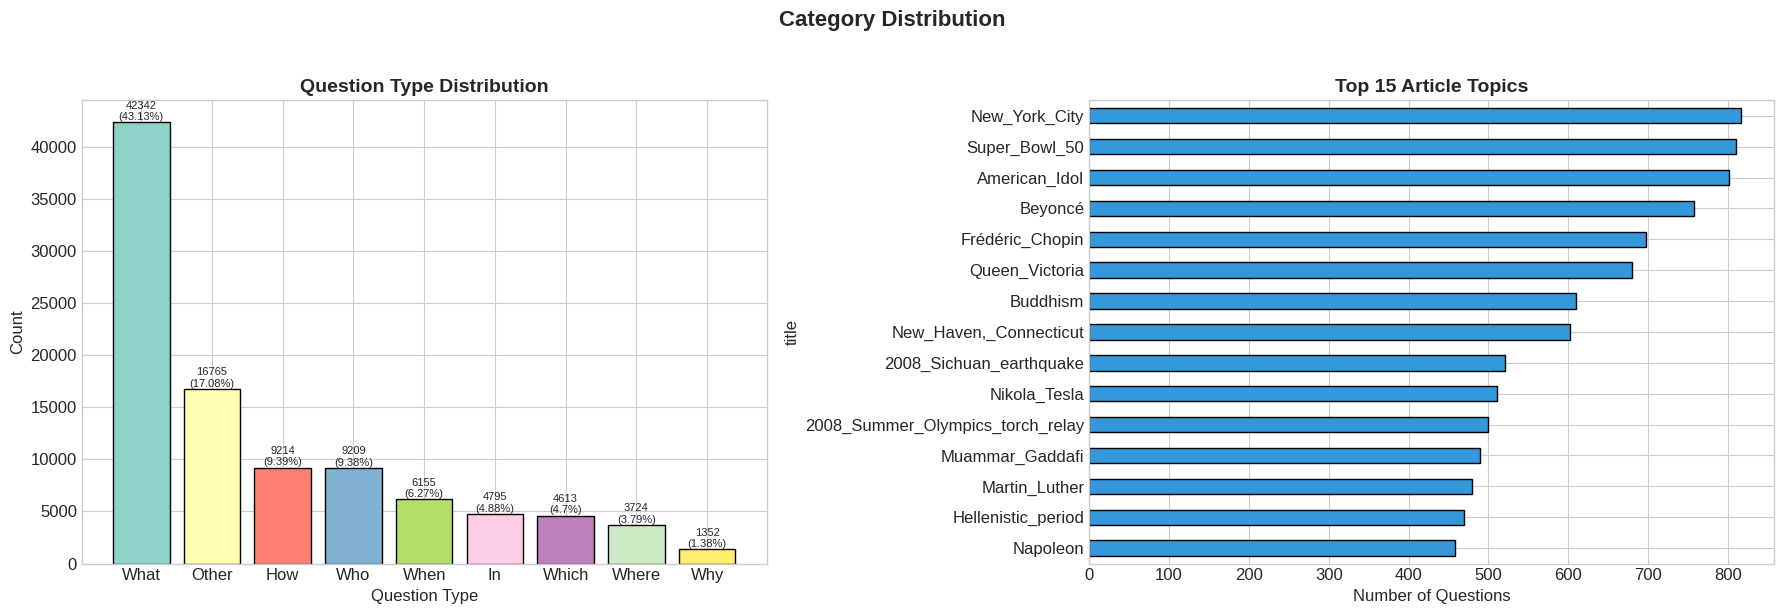

In [4]:
log('\n=== SECTION 3: CATEGORY DISTRIBUTION ===')

# --- Question Type Distribution ---
qtype_counts = df['question_category'].value_counts()
qtype_pct = (qtype_counts / len(df) * 100).round(2)

log('Question Type Distribution:')
qtype_data = []
for cat in qtype_counts.index:
    entry = {'category': cat, 'count': int(qtype_counts[cat]), 'pct': float(qtype_pct[cat])}
    qtype_data.append(entry)
    log(f'  {cat}: {qtype_counts[cat]} ({qtype_pct[cat]}%)')

imbalance_ratio_q = qtype_counts.max() / qtype_counts.min()
log(f'  Imbalance ratio (question types): {imbalance_ratio_q:.2f}x')

# --- Top Article Topics ---
title_counts = df['title'].value_counts()
top_titles = title_counts.head(15)
log('\nTop 15 Article Topics:')
title_data = []
for t in top_titles.index:
    entry = {'title': t, 'count': int(top_titles[t])}
    title_data.append(entry)
    log(f'  {t}: {top_titles[t]} questions')

json_data['category_distribution'] = {
    'question_types': qtype_data,
    'question_type_imbalance_ratio': round(float(imbalance_ratio_q), 2),
    'top_articles': title_data,
    'total_unique_articles': n_unique_titles
}
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Question types
colors = plt.cm.Set3(np.linspace(0, 1, len(qtype_counts)))
bars = axes[0].bar(qtype_counts.index, qtype_counts.values, color=colors, edgecolor='black')
for bar, val, pct in zip(bars, qtype_counts.values, qtype_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val}\n({pct}%)', ha='center', fontsize=8)
axes[0].set_title('Question Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Question Type')
axes[0].set_ylabel('Count')

# Top titles
top_titles.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Top 15 Article Topics', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Questions')
axes[1].invert_yaxis()

plt.suptitle('Category Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_01_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 📏 Text Length Analysis


=== SECTION 4: TEXT LENGTH ANALYSIS ===
  CONTEXT: words mean=120.2, median=110.0, min=20, max=653, std=50.2
  QUESTION: words mean=10.1, median=10.0, min=1, max=40, std=3.6
  ANSWER: words mean=3.1, median=2.0, min=1, max=43, std=3.4


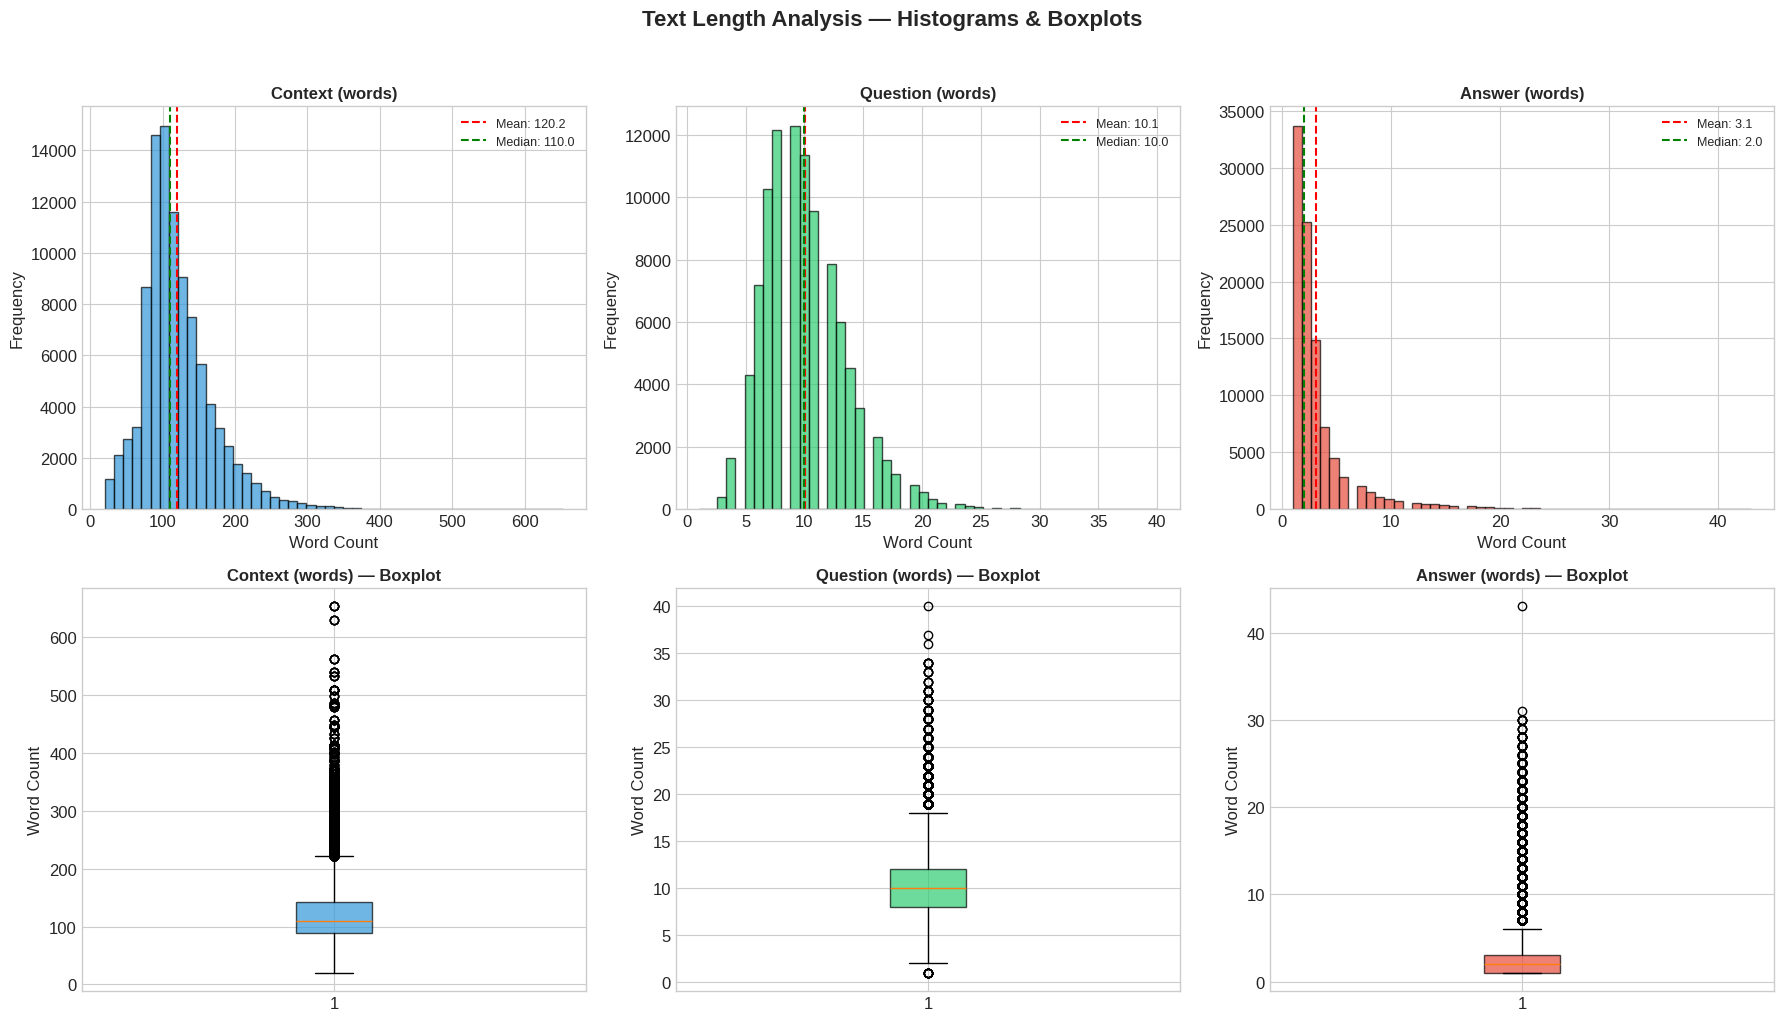

,Component,Mean,Median,Std,Min,Max
0,Context,120.2,110.0,50.2,20,653
1,Question,10.1,10.0,3.6,1,40
2,Answer,3.1,2.0,3.4,1,43


In [5]:
log('\n=== SECTION 4: TEXT LENGTH ANALYSIS ===')

length_stats = {}
for component, wc_col, cc_col in [('context', 'context_word_count', 'context_char_count'),
                                    ('question', 'question_word_count', 'question_char_count'),
                                    ('answer', 'answer_word_count', 'answer_char_count')]:
    stats = {
        'word_count': {
            'mean': round(float(df[wc_col].mean()), 1),
            'median': round(float(df[wc_col].median()), 1),
            'std': round(float(df[wc_col].std()), 1),
            'min': int(df[wc_col].min()),
            'max': int(df[wc_col].max()),
            'q1': round(float(df[wc_col].quantile(0.25)), 1),
            'q3': round(float(df[wc_col].quantile(0.75)), 1),
            'histogram_values': np.histogram(df[wc_col], bins=50)[0].tolist(),
            'histogram_edges': np.histogram(df[wc_col], bins=50)[1].tolist()
        },
        'char_count': {
            'mean': round(float(df[cc_col].mean()), 1),
            'median': round(float(df[cc_col].median()), 1),
            'std': round(float(df[cc_col].std()), 1),
            'min': int(df[cc_col].min()),
            'max': int(df[cc_col].max())
        }
    }
    length_stats[component] = stats
    log(f'  {component.upper()}: words mean={stats["word_count"]["mean"]}, '
        f'median={stats["word_count"]["median"]}, min={stats["word_count"]["min"]}, '
        f'max={stats["word_count"]["max"]}, std={stats["word_count"]["std"]}')

json_data['text_length'] = length_stats
save_json()

# --- Histograms ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

components = [('context_word_count', 'Context (words)', '#3498db'),
              ('question_word_count', 'Question (words)', '#2ecc71'),
              ('answer_word_count', 'Answer (words)', '#e74c3c')]

for i, (col, title, color) in enumerate(components):
    # Histogram
    axes[0, i].hist(df[col], bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--',
                       label=f'Mean: {df[col].mean():.1f}')
    axes[0, i].axvline(df[col].median(), color='green', linestyle='--',
                       label=f'Median: {df[col].median():.1f}')
    axes[0, i].set_title(title, fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Word Count')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].legend(fontsize=9)
    
    # Boxplot
    bp = axes[1, i].boxplot(df[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    axes[1, i].set_title(f'{title} — Boxplot', fontsize=12, fontweight='bold')
    axes[1, i].set_ylabel('Word Count')

plt.suptitle('Text Length Analysis — Histograms & Boxplots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_02_text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
summary_rows = []
for comp in ['context', 'question', 'answer']:
    wc = length_stats[comp]['word_count']
    summary_rows.append({'Component': comp.capitalize(), 'Mean': wc['mean'], 'Median': wc['median'],
                         'Std': wc['std'], 'Min': wc['min'], 'Max': wc['max']})
pd.DataFrame(summary_rows)

## 5. 🔤 Word Frequency / Lexical Analysis


=== SECTION 5: WORD FREQUENCY ANALYSIS ===
Question vocabulary size (excl stopwords): 37164
Context vocabulary size (excl stopwords): 74920
Answer vocabulary size (excl stopwords): 36608
Stopword ratio in questions: 47.1%

Top 20 question words: ['many', 'year', 'name', 'first', 'type', 'used', 'new', 'city', 'people', 'one', 'two', 'called', 'much', 'use', 'time', 'war', 'located', 'country', 'known', 'group']
Top 20 context words: ['also', 'one', 'first', 'new', 'city', 'many', 'two', 'time', 'world', 'states', 'state', 'used', 'may', 'century', 'united', 'would', 'war', 'known', 'including', 'years']
Top 20 answer words: ['million', 'two', 'century', 'new', 'one', 'three', 'united', 'years', 'war', 'world', 'states', 'state', 'four', 'john', 'city', 'may', 'national', 'system', 'five', 'government']


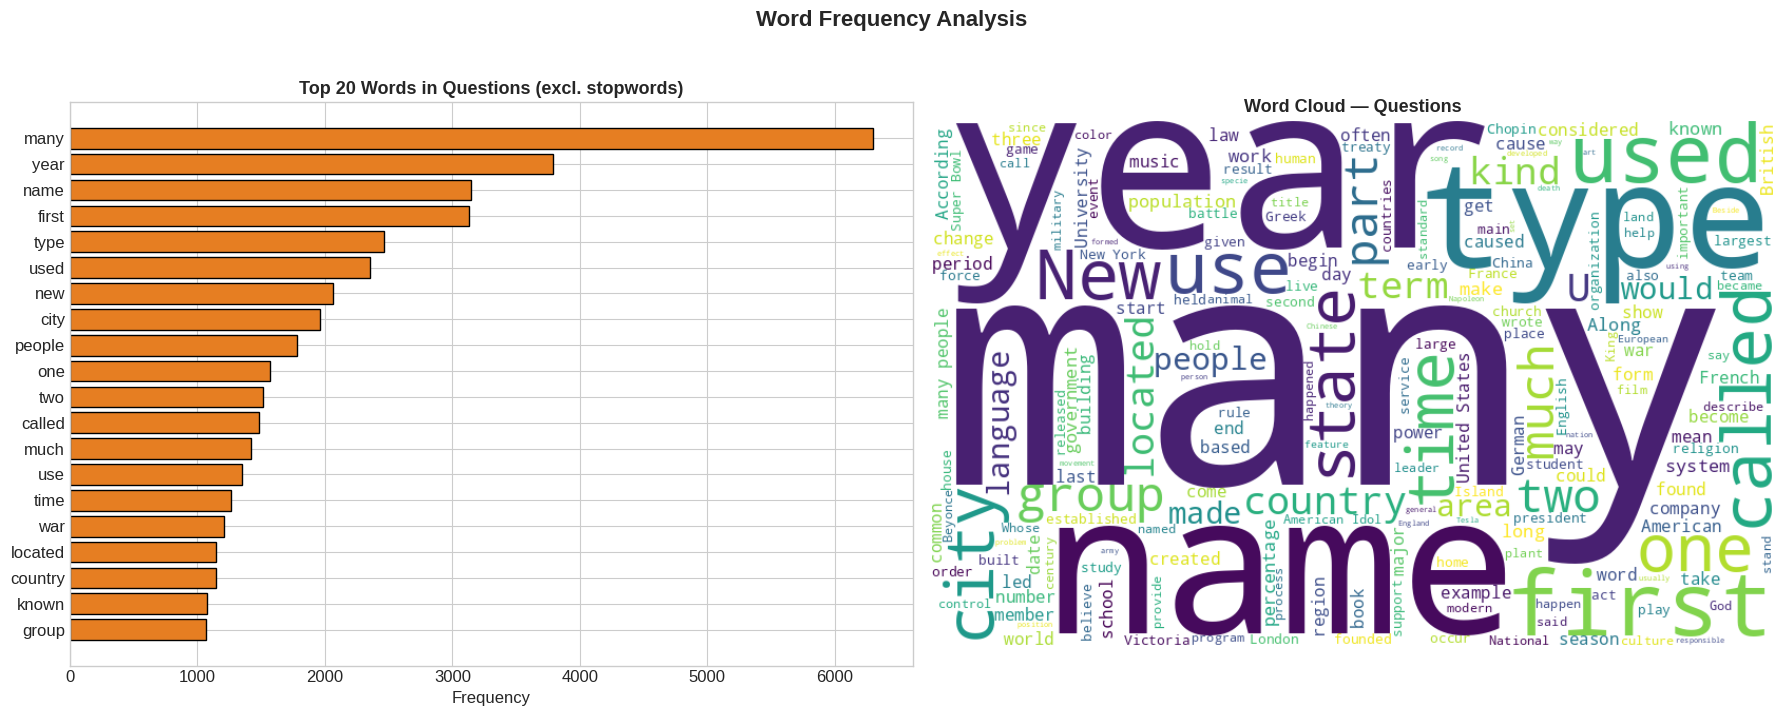

In [6]:
log('\n=== SECTION 5: WORD FREQUENCY ANALYSIS ===')

def tokenize_clean(texts, stop_words=STOP_WORDS, min_len=3):
    """Tokenize, lowercase, remove stopwords and short words"""
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        words = [w for w in words if w not in stop_words and len(w) >= min_len]
        all_words.extend(words)
    return all_words

# --- Questions ---
q_words = tokenize_clean(df['question'])
q_freq = Counter(q_words)
q_top30 = q_freq.most_common(30)

# --- Contexts ---
c_words = tokenize_clean(df['context'])
c_freq = Counter(c_words)
c_top30 = c_freq.most_common(30)

# --- Answers ---
a_words = tokenize_clean(df['answer_text'])
a_freq = Counter(a_words)
a_top30 = a_freq.most_common(30)

# Vocabulary stats
q_vocab_size = len(q_freq)
c_vocab_size = len(c_freq)
a_vocab_size = len(a_freq)

# Stopword ratio
q_all_raw = []
for q in df['question']:
    q_all_raw.extend(re.findall(r'\b[a-z]+\b', str(q).lower()))
q_stopword_ratio = sum(1 for w in q_all_raw if w in STOP_WORDS) / len(q_all_raw) * 100

log(f'Question vocabulary size (excl stopwords): {q_vocab_size}')
log(f'Context vocabulary size (excl stopwords): {c_vocab_size}')
log(f'Answer vocabulary size (excl stopwords): {a_vocab_size}')
log(f'Stopword ratio in questions: {q_stopword_ratio:.1f}%')
log(f'\nTop 20 question words: {[w for w, _ in q_top30[:20]]}')
log(f'Top 20 context words: {[w for w, _ in c_top30[:20]]}')
log(f'Top 20 answer words: {[w for w, _ in a_top30[:20]]}')

json_data['word_frequency'] = {
    'question': {'vocab_size': q_vocab_size, 'stopword_ratio_pct': round(q_stopword_ratio, 1),
                 'top_30': [{'word': w, 'count': c} for w, c in q_top30]},
    'context': {'vocab_size': c_vocab_size,
                'top_30': [{'word': w, 'count': c} for w, c in c_top30]},
    'answer': {'vocab_size': a_vocab_size,
               'top_30': [{'word': w, 'count': c} for w, c in a_top30]}
}
save_json()

# --- Charts: Top words bar + Word Cloud ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 20 question words
words20, counts20 = zip(*q_top30[:20])
axes[0].barh(range(len(words20)), counts20, color='#e67e22', edgecolor='black')
axes[0].set_yticks(range(len(words20)))
axes[0].set_yticklabels(words20)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Words in Questions (excl. stopwords)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Word cloud
wc = WordCloud(width=800, height=500, background_color='white',
               stopwords=STOP_WORDS.union({'what','who','when','where','how','which','why',
                                           'did','does','do','is','was','are','were','the'}),
               max_words=200, colormap='viridis', random_state=42)
wc.generate(' '.join(df['question'].values))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Questions', fontsize=13, fontweight='bold')

plt.suptitle('Word Frequency Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_03_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 📊 N-gram Analysis


=== SECTION 6: N-GRAM ANALYSIS ===
Top 15 Bigrams (Questions):
  "many people": 495
  "united states": 448
  "new york": 408
  "super bowl": 355
  "american idol": 325
  "take place": 271
  "notre dame": 228
  "another name": 185
  "world war": 177
  "mexico city": 164
  "many years": 160
  "premier league": 149
  "san diego": 147
  "york city": 141
  "prime minister": 138

Top 15 Trigrams (Questions):
  "new york city": 141
  "season american idol": 45
  "east india company": 43
  "arena football league": 33
  "term used describe": 31
  "many people died": 30
  "many people lived": 30
  "many square miles": 29
  "roman catholic church": 25
  "many people live": 22
  "seven years war": 21
  "many people killed": 20
  "late middle ages": 20
  "fifa world cup": 20
  "endangered species act": 20


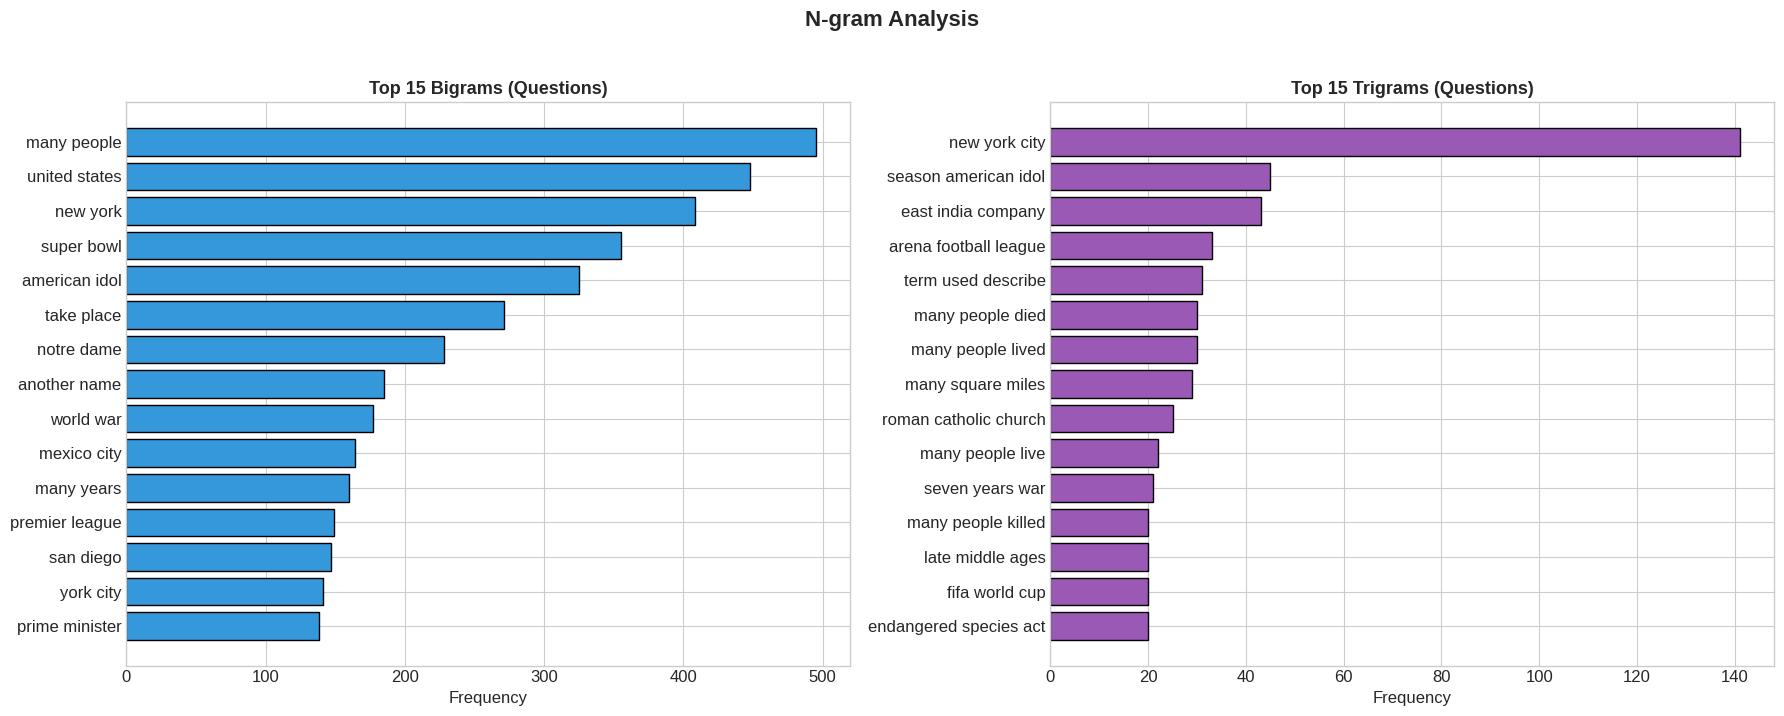

In [7]:
log('\n=== SECTION 6: N-GRAM ANALYSIS ===')

def get_ngrams(texts, n, stop_words=STOP_WORDS, top_k=20):
    """Extract top-k n-grams from list of texts"""
    all_ngrams = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        words = [w for w in words if w not in stop_words and len(w) >= 3]
        all_ngrams.extend(list(nltk_ngrams(words, n)))
    return Counter(all_ngrams).most_common(top_k)

# Bigrams & Trigrams for questions
q_bigrams = get_ngrams(df['question'], 2, top_k=20)
q_trigrams = get_ngrams(df['question'], 3, top_k=20)

log('Top 15 Bigrams (Questions):')
bigram_data = []
for gram, count in q_bigrams[:15]:
    label = ' '.join(gram)
    bigram_data.append({'ngram': label, 'count': count})
    log(f'  "{label}": {count}')

log('\nTop 15 Trigrams (Questions):')
trigram_data = []
for gram, count in q_trigrams[:15]:
    label = ' '.join(gram)
    trigram_data.append({'ngram': label, 'count': count})
    log(f'  "{label}": {count}')

json_data['ngram_analysis'] = {
    'question_bigrams': bigram_data,
    'question_trigrams': trigram_data
}
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bigrams
bi_labels = [d['ngram'] for d in bigram_data[:15]]
bi_counts = [d['count'] for d in bigram_data[:15]]
axes[0].barh(range(len(bi_labels)), bi_counts, color='#3498db', edgecolor='black')
axes[0].set_yticks(range(len(bi_labels)))
axes[0].set_yticklabels(bi_labels)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 Bigrams (Questions)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Trigrams
tri_labels = [d['ngram'] for d in trigram_data[:15]]
tri_counts = [d['count'] for d in trigram_data[:15]]
axes[1].barh(range(len(tri_labels)), tri_counts, color='#9b59b6', edgecolor='black')
axes[1].set_yticks(range(len(tri_labels)))
axes[1].set_yticklabels(tri_labels)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 15 Trigrams (Questions)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('N-gram Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_04_ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🎯 Category-Specific Analysis


=== SECTION 7: CATEGORY-SPECIFIC ANALYSIS ===
  Top words for "What": ['name', 'type', 'used', 'year', 'called']
  Top words for "How": ['many', 'much', 'long', 'people', 'city']
  Top words for "Who": ['first', 'wrote', 'president', 'new', 'led']
  Top words for "When": ['first', 'begin', 'become', 'start', 'die']
  Top words for "Where": ['located', 'first', 'found', 'held', 'place']
  Top words for "Why": ['used', 'would', 'use', 'people', 'many']
  What: avg Q=9.9 words, avg A=3.5 words
  How: avg Q=9.9 words, avg A=3.0 words
  Who: avg Q=9.0 words, avg A=2.8 words
  When: avg Q=8.6 words, avg A=2.3 words
  Where: avg Q=8.3 words, avg A=3.1 words
  Why: avg Q=9.6 words, avg A=7.9 words
  What avg answer position: 0.429 (0=start, 1=end)
  How avg answer position: 0.446 (0=start, 1=end)
  Who avg answer position: 0.402 (0=start, 1=end)
  When avg answer position: 0.394 (0=start, 1=end)
  Where avg answer position: 0.426 (0=start, 1=end)
  Why avg answer position: 0.472 (0=start, 1=e

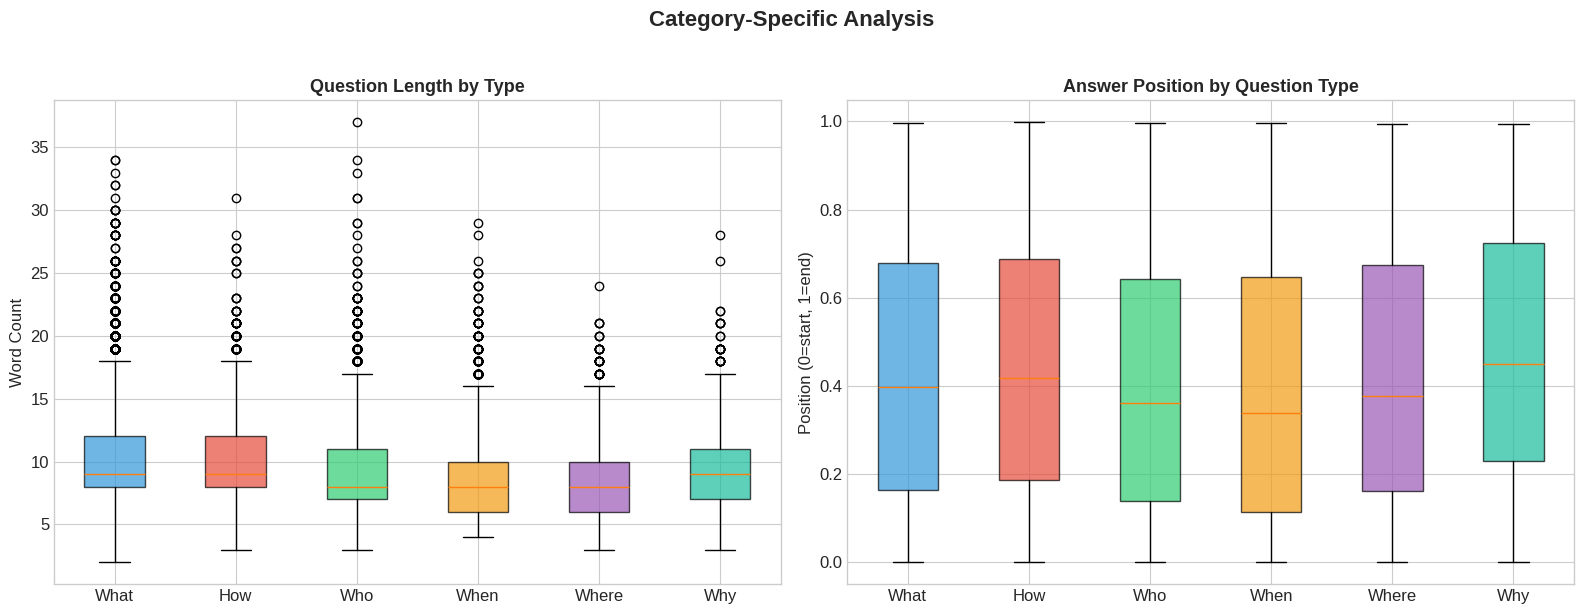

In [8]:
log('\n=== SECTION 7: CATEGORY-SPECIFIC ANALYSIS ===')

# --- Top words per question type ---
top_qtypes = ['What', 'How', 'Who', 'When', 'Where', 'Why']
words_per_category = {}

for qtype in top_qtypes:
    subset = df[df['question_category'] == qtype]['question']
    words = tokenize_clean(subset)
    top10 = Counter(words).most_common(10)
    words_per_category[qtype] = [{'word': w, 'count': c} for w, c in top10]
    log(f'  Top words for "{qtype}": {[w for w, _ in top10[:5]]}')

# --- Length by question type ---
length_by_qtype = []
for qtype in top_qtypes:
    subset = df[df['question_category'] == qtype]
    stats = {
        'category': qtype,
        'count': int(len(subset)),
        'avg_question_words': round(float(subset['question_word_count'].mean()), 1),
        'avg_answer_words': round(float(subset['answer_word_count'].mean()), 1),
        'avg_context_words': round(float(subset['context_word_count'].mean()), 1)
    }
    length_by_qtype.append(stats)
    log(f'  {qtype}: avg Q={stats["avg_question_words"]} words, '
        f'avg A={stats["avg_answer_words"]} words')

# --- Answer position analysis ---
df['answer_position_ratio'] = df['answer_start'] / df['context_char_count']
pos_by_qtype = {}
for qtype in top_qtypes:
    subset = df[df['question_category'] == qtype]
    pos_by_qtype[qtype] = round(float(subset['answer_position_ratio'].mean()), 3)
    log(f'  {qtype} avg answer position: {pos_by_qtype[qtype]:.3f} (0=start, 1=end)')

json_data['category_specific'] = {
    'words_per_category': words_per_category,
    'length_by_category': length_by_qtype,
    'answer_position_by_category': pos_by_qtype
}
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Length by category (boxplot)
qtype_data_for_box = [df[df['question_category'] == qt]['question_word_count'].values for qt in top_qtypes]
bp = axes[0].boxplot(qtype_data_for_box, labels=top_qtypes, patch_artist=True)
colors_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Question Length by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Word Count')

# Answer position by category
ans_pos_data = [df[df['question_category'] == qt]['answer_position_ratio'].values for qt in top_qtypes]
bp2 = axes[1].boxplot(ans_pos_data, labels=top_qtypes, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Answer Position by Question Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Position (0=start, 1=end)')

plt.suptitle('Category-Specific Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_05_category_specific.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 💡 Key Insights & Suggestions

In [9]:
log('\n=== SECTION 8: KEY INSIGHTS ===')

insights = {
    'dataset_characteristics': [
        f'Dataset contains {n_total} QA pairs from {n_unique_titles} Wikipedia articles',
        f'No missing values detected',
        f'Context: avg {length_stats["context"]["word_count"]["mean"]} words (range {length_stats["context"]["word_count"]["min"]}–{length_stats["context"]["word_count"]["max"]})',
        f'Question: avg {length_stats["question"]["word_count"]["mean"]} words',
        f'Answer: avg {length_stats["answer"]["word_count"]["mean"]} words — very short, ideal for extractive QA',
        f'"What" questions dominate at {qtype_pct["What"]:.1f}% — imbalance ratio {imbalance_ratio_q:.1f}x',
        f'Diverse topics spanning history, sports, science, geography, entertainment',
        f'Question vocabulary size: {q_vocab_size:,} unique words (excl. stopwords)',
        f'Stopword ratio in questions: {q_stopword_ratio:.1f}%',
        f'Answers tend to appear early in context (position skewed toward 0.0)'
    ],
    'preprocessing_suggestions': [
        'Tokenization: use WordPiece or BPE tokenizer for transformer models',
        'Lowercasing: recommended for consistency',
        'Stopword removal: helpful for TF-IDF, NOT for transformer models (BERT, etc.)',
        'Punctuation removal: optional, depends on model',
        'Stemming/Lemmatization: useful for traditional ML, not for transformers',
        'Consider answer span position as feature for model training',
        'Handle question type imbalance — What-questions may dominate model behavior',
        'English-only dataset — not suitable for multilingual QA',
        'SQuAD 1.1 has no unanswerable questions — consider SQuAD 2.0 for robustness'
    ]
}

for section, items in insights.items():
    log(f'\n  {section.upper()}:')
    for item in items:
        log(f'    • {item}')

json_data['insights'] = insights
save_json()

log(f'\n{"=" * 70}')
log(f'Stats exported to: {LOG_FILE}')
log(f'JSON data exported to: {JSON_FILE}')
log(f'{"=" * 70}')

print(f'\n✅ All stats saved to {LOG_FILE}')
print(f'✅ JSON data saved to {JSON_FILE}')
print(f'✅ All figures saved as PNG')


=== SECTION 8: KEY INSIGHTS ===

  DATASET_CHARACTERISTICS:
    • Dataset contains 98169 QA pairs from 490 Wikipedia articles
    • No missing values detected
    • Context: avg 120.2 words (range 20–653)
    • Question: avg 10.1 words
    • Answer: avg 3.1 words — very short, ideal for extractive QA
    • "What" questions dominate at 43.1% — imbalance ratio 31.3x
    • Diverse topics spanning history, sports, science, geography, entertainment
    • Question vocabulary size: 37,164 unique words (excl. stopwords)
    • Stopword ratio in questions: 47.1%
    • Answers tend to appear early in context (position skewed toward 0.0)

  PREPROCESSING_SUGGESTIONS:
    • Tokenization: use WordPiece or BPE tokenizer for transformer models
    • Lowercasing: recommended for consistency
    • Stopword removal: helpful for TF-IDF, NOT for transformer models (BERT, etc.)
    • Punctuation removal: optional, depends on model
    • Stemming/Lemmatization: useful for traditional ML, not for transformer